# 15. The modelling improvement round: bias correction, intervals, a drift monitor, competitor shares

**Question.** Can we fix the weaknesses Phase 4 stated (a segment model that runs about 7% high, intervals that are conservative or missing, a monitor blind to slow drift) and show the brand manager who gained after Zilretta's 2022 turn?

**Answer in one line.** The bias can be removed (+6.9% to +1.4%) for a log-loss gain of about 0.05%; neither interval method passes its rule; a CUSUM monitor catches 0.2 pp a month drifts that the current alarm never does; and Zilretta lost far more than the steroid category while triamcinolone IR (Kenalog and generics) lost the least.

**What this notebook is.** A reader of the stored result, not a re-run. The rules were fixed in [`modelling_improvement_plan.md`](../docs/modelling_improvement_plan.md) (DL-73) before any build or run; the round was run once and repeated with byte-identical output. Re-run with `python -m oa_market_intelligence.modeling.improvement_round --run`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))
from oa_market_intelligence.modeling import improvement_round as ir

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
results = json.loads(
    (ROOT / "data" / "reference" / "modelling_improvement_results.json").read_text("utf-8")
)
m1, m4, m5, m6 = results["m1"], results["m4"], results["m5"], results["m6"]
print("seed", results["seed"], "| bootstrap draws", results["n_boot"])
print("rules in code: window", ir.OFFSET_WINDOW, "| bias tolerance", ir.BIAS_TOLERANCE,
      "| CUSUM grid", ir.H_GRID, "| minimum run length", ir.ARL_MIN)

seed 0 | bootstrap draws 2000
rules in code: window 12 | bias tolerance 0.03 | CUSUM grid (3, 4, 5, 6, 8) | minimum run length 48


## 1. M1: removing the segment model's bias

The serving logistic regression plus a logit offset fitted on the model's own predictions for the previous 12 months (at least 3). Pass: the lower end of the paired log-loss gain is above zero at the 5th percentile **and** the bias is within 3%; robust if that holds without COVID and without the 2024 dip.

In [2]:
rows = []
for scenario, d in m1["scenarios"].items():
    rows.append({"run": scenario, "log-loss gain": d["estimate"], "lower end (5th pct)": d["low"],
                 "months better": f"{d['months_better']} / {d['n_test_months']}",
                 "bias before": d["bias_before"], "bias after": d["bias_after"],
                 "passes": d["passes"]})
print("Verdict:", m1["verdict"])
pd.DataFrame(rows).round(6)

Verdict: robust


,run,log-loss gain,lower end (5th pct),months better,bias before,bias after,passes
0,main,0.000054,0.000023,28 / 46,0.068712,0.013568,True
1,covid_removed,0.000056,0.000025,26 / 43,0.072193,0.008063,True
2,dip_2024_removed,0.000056,0.000026,25 / 41,0.069498,0.017028,True


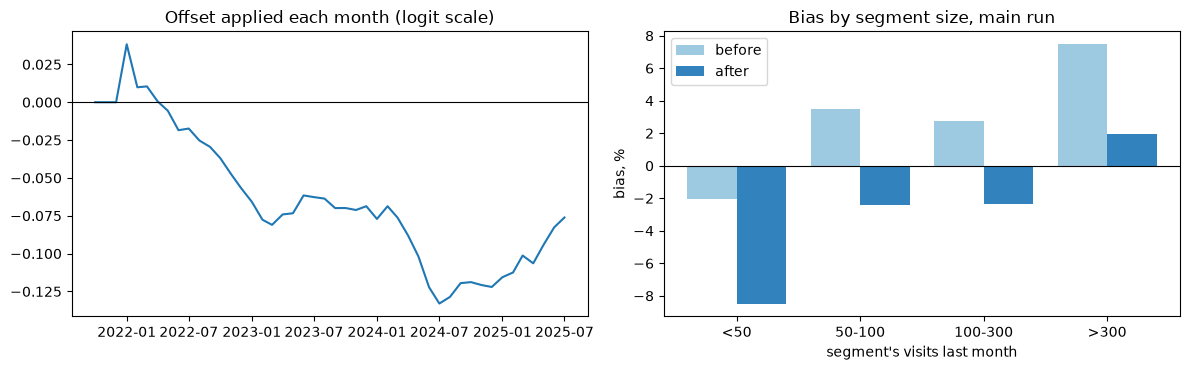

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
main = m1["scenarios"]["main"]
offsets = pd.Series(main["offsets"])
offsets.index = pd.to_datetime(offsets.index.astype(str), format="%Y%m")
axes[0].plot(offsets.index, offsets.values, color="#1f77b4")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Offset applied each month (logit scale)")
labels = list(main["bias_by_size"])
before = [main["bias_by_size"][k]["before"] * 100 for k in labels]
after = [main["bias_by_size"][k]["after"] * 100 for k in labels]
x = np.arange(len(labels))
axes[1].bar(x - 0.2, before, 0.4, label="before", color="#9ecae1")
axes[1].bar(x + 0.2, after, 0.4, label="after", color="#3182bd")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(x, labels)
axes[1].set_xlabel("segment's visits last month")
axes[1].set_ylabel("bias, %")
axes[1].set_title("Bias by segment size, main run")
axes[1].legend()
plt.tight_layout()
plt.show()

The gain is real and tiny (about 0.05% of log-loss). The correction removes the bias of the large segments, where most visits are, and **over-corrects the smallest ones** (under 50 visits: -2% to -8.5%). The plan's overall bias test does not see that; it is stated here.

## 2. M4: prediction intervals

**National forecast.** Adaptive conformal intervals against the served ones: pass if coverage is within two binomial standard errors of 90% **and** the mean width is at least 10% below the served width.

In [4]:
b = m4["task_b"]
table = pd.DataFrame(
    {
        "coverage of the 90% interval": [b["served"]["coverage90"], b["aci"]["coverage90"]],
        "mean width (pp)": [b["served"]["width90"], b["aci"]["width90"]],
    },
    index=["served (last month, empirical)", "adaptive conformal"],
)
print("coverage gate:", b["coverage_gate"])
print(f"width change: {-b['width_cut']:+.1%}   passes: {b['passes']}")
table.round(3)

coverage gate: {'ok': True, 'low': 0.8133974596215562, 'high': 0.9866025403784439}
width change: +9.8%   passes: False


,coverage of the 90% interval,mean width (pp)
"served (last month, empirical)",0.958,0.639
adaptive conformal,0.958,0.701


**Segments.** Conformal intervals on standardised residuals. Pass: overall coverage within 3 points of 90% and each size bucket within 5.

In [5]:
a = m4["task_a"]
rows = [{"bucket": "all rows", **{k: a["overall"][k] for k in ("n", "coverage", "mean_width")},
         "low": a["overall"]["interval"][0], "high": a["overall"]["interval"][1]}]
for label, d in a["buckets"].items():
    rows.append({"bucket": label, "n": d["n"], "coverage": d["coverage"],
                 "mean_width": d["mean_width"], "low": d["interval"][0], "high": d["interval"][1]})
frame = pd.DataFrame(rows)
print("overall within 3 points:", a["overall_ok"], "| every bucket within 5 points:", a["buckets_ok"])
frame.round(4)

overall within 3 points: True | every bucket within 5 points: False


,bucket,n,coverage,mean_width,low,high
0,all rows,5157,0.8918,0.0395,0.8834,0.8992
1,<50,881,0.9285,0.0611,0.9144,0.9424
2,50-100,991,0.9314,0.0543,0.9162,0.9448
3,100-300,1487,0.9146,0.0411,0.9009,0.9281
4,>300,1798,0.8331,0.0194,0.8123,0.8524


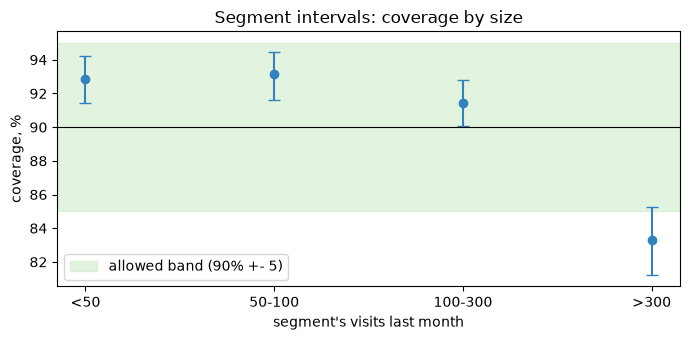

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
labels = list(a["buckets"])
cover = [a["buckets"][k]["coverage"] * 100 for k in labels]
low = [a["buckets"][k]["interval"][0] * 100 for k in labels]
high = [a["buckets"][k]["interval"][1] * 100 for k in labels]
ax.errorbar(range(len(labels)), cover, yerr=[np.subtract(cover, low), np.subtract(high, cover)],
            fmt="o", color="#3182bd", capsize=4)
ax.axhspan(85, 95, color="#c7e9c0", alpha=0.5, label="allowed band (90% +- 5)")
ax.axhline(90, color="black", lw=0.8)
ax.set_xticks(range(len(labels)), labels)
ax.set_xlabel("segment's visits last month")
ax.set_ylabel("coverage, %")
ax.set_title("Segment intervals: coverage by size")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

Neither passes. The adaptive national interval is about 10% **wider** than the served one at the same coverage, and the segment intervals are on target overall but under-cover the largest segments (83% against 90%), where the binomial scale ignores the real month-to-month movement of the share. None of these intervals should be shown as 90% intervals.

## 3. M5: a drift monitor

Two-sided CUSUM (k = 0.5) on the served forecast's standardised one-step changes. The threshold is the smallest on the grid with a no-drift average run length of at least 48 months. Pass: at least 80% detection within 12 months at 0.2 pp a month, where the current alarm detects 0%.

In [7]:
arl = pd.DataFrame(m5["cusum"]["arl"]).T
arl.index.name = "threshold h"
print("chosen threshold:", m5["cusum"]["h"])
arl.round(3)

chosen threshold: 3.0


,arl,no_alarm_share
threshold h,,
3,52.730,0.000
4,188.264,0.191
5,360.272,0.624
6,439.296,0.870
8,474.233,0.984


In [8]:
detection = pd.DataFrame(m5["cusum"]["detection"])
table = detection.pivot(index="drift_pp_per_month", columns="horizon_months", values="detection_rate")
table.columns = [f"within {c} months" for c in table.columns]
print("Alarms of the CUSUM on the real series:", m5["cusum"]["real_alarms"] or "none")
print("Detection at 0.2 pp a month within 12 months:", m5["cusum"]["detection_at_pass_point"],
      "| passes:", m5["cusum"]["passes"])
table

Alarms of the CUSUM on the real series: none
Detection at 0.2 pp a month within 12 months: 1.0 | passes: True


,within 6 months,within 12 months
drift_pp_per_month,,
0.05,0.000000,0.000000
0.10,0.000000,0.135135
0.20,0.729730,1.000000
0.30,0.972973,1.000000


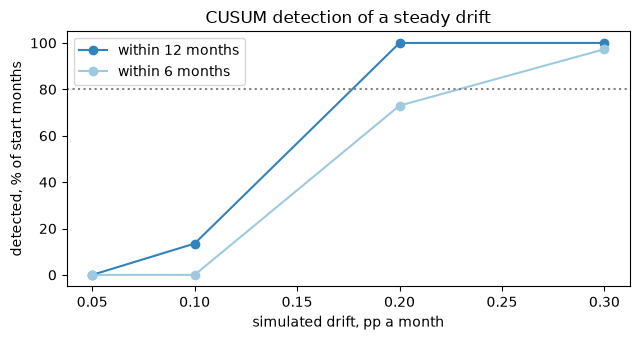

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
for horizon, color in ((12, "#3182bd"), (6, "#9ecae1")):
    part = detection[detection.horizon_months == horizon]
    ax.plot(part.drift_pp_per_month, part.detection_rate * 100, "o-", color=color,
            label=f"within {horizon} months")
ax.axhline(80, color="gray", ls=":")
ax.set_xlabel("simulated drift, pp a month")
ax.set_ylabel("detected, % of start months")
ax.set_title("CUSUM detection of a steady drift")
ax.legend()
plt.tight_layout()
plt.show()

The CUSUM catches drifts of 0.2 pp a month or more reliably and does not catch 0.05 to 0.1. The real decline since 2022 is about 0.03 pp a month and the CUSUM raised **no alarm on the real series**, as the plan expected. Its no-drift run length (52.7 months) is only just above the minimum.

**Decision metric (reported, not judged).** The overlap of the predicted and realised top-10 segments by headroom:

In [10]:
pd.Series(m5["decision_metric"]).to_frame("value")

,value
k,10
min_visits_last_month,100
n_months,46
model_overlap,0.83913
baseline_overlap,0.83913
difference,0.0
difference_interval,"[-0.017499999999999998, 0.0173913043478261]"


The model and the last-month baseline give the same overlap: headroom is dominated by visit volume, so both rankings pick the same large segments. The model adds nothing to this ranking.

## 4. M6: who gained after 2022? (descriptive)

Shares of product-visits inside IQVIA's panel; a patient visit can count under more than one product, and the panel-coverage caveat (DL-62) applies to every number. Product groups are frozen in `data/reference/competitor_groups.csv`.

In [11]:
print(m6["caveat"])
year = pd.DataFrame(m6["by_year"]).set_index("year")
year[["months", "zilretta_visits", "triamcinolone_ir_visits",
      "other_injectable_corticosteroid_visits",
      "zilretta_share_of_injectable_steroids_pct",
      "zilretta_share_against_triamcinolone_ir_pct"]]

Shares of product-visits inside IQVIA's panel; a patient visit can count under more than one product. The panel-coverage caveat of DL-62 applies: the size of the fall after 2022 is not confirmed by company sales.


,months,zilretta_visits,triamcinolone_ir_visits,other_injectable_corticosteroid_visits,zilretta_share_of_injectable_steroids_pct,zilretta_share_against_triamcinolone_ir_pct
year,,,,,,
2019,5,7231.0,141558.0,195569.0,2.0998,4.8599
2020,12,19773.0,305823.0,406556.0,2.7007,6.0729
2021,12,27592.0,399829.0,469214.0,3.0773,6.4555
2022,12,29449.0,529434.0,401646.0,3.0659,5.2693
2023,12,25478.0,506242.0,377445.0,2.8024,4.7916
2024,12,16336.0,445618.0,276502.0,2.2122,3.5363
2025,7,9260.0,282126.0,167335.0,2.0187,3.1779


In [12]:
gained = pd.DataFrame(m6["who_gained"]["groups"]).T
print("peak year", m6["who_gained"]["peak_year"], "| latest window", m6["who_gained"]["latest_window"])
print(f"whole category's visits: {m6['who_gained']['category_visits_change_pct']:+.1f}%")
gained.round(2)

peak year 2022 | latest window [202408, 202507]
whole category's visits: -19.5%


,visits_peak_year,visits_latest_12,share_peak_year_pct,share_latest_12_pct,visits_change_pct
zilretta,29449.0,15906.0,3.07,2.06,-45.99
triamcinolone_ir,529434.0,477341.0,55.12,61.76,-9.84
other_injectable_corticosteroid,401646.0,279617.0,41.82,36.18,-30.38


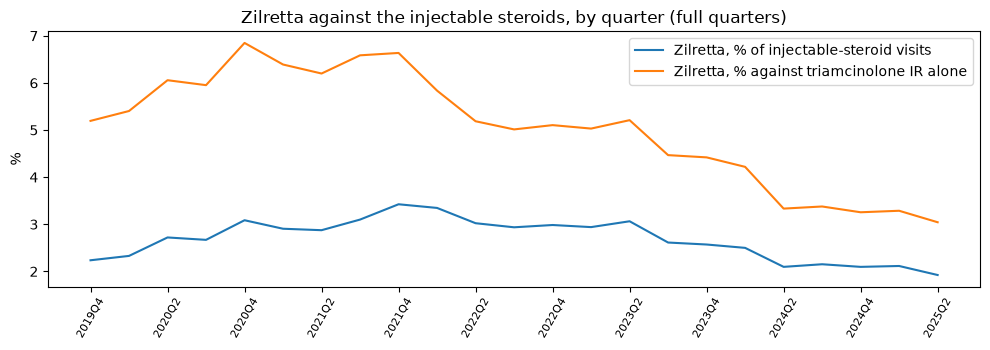

In [13]:
quarter = pd.DataFrame(m6["by_quarter"])
quarter = quarter[~quarter.quarter.isin(["2019Q3", "2025Q3"])]  # partial quarters
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(quarter.quarter, quarter.zilretta_share_of_injectable_steroids_pct, color="#1f77b4",
        label="Zilretta, % of injectable-steroid visits")
ax.plot(quarter.quarter, quarter.zilretta_share_against_triamcinolone_ir_pct, color="#ff7f0e",
        label="Zilretta, % against triamcinolone IR alone")
ax.set_xticks(range(0, len(quarter), 2), quarter.quarter.iloc[::2], rotation=60, fontsize=8)
ax.set_ylabel("%")
ax.set_title("Zilretta against the injectable steroids, by quarter (full quarters)")
ax.legend()
plt.tight_layout()
plt.show()

From 2022 to the latest 12 months Zilretta's visits fell 46% while the three groups together fell 19.5%; triamcinolone IR fell 9.8% and its share of the injectable-steroid visits rose from 55% to 62%, mostly at the expense of the other steroids. These tables describe; they do not show that any competitor took Zilretta's visits, and part of the category's fall is the early-2024 dip.

## 5. What we conclude

1. **M1:** the bias can be removed, with a log-loss gain of about 0.05% and an over-correction in the smallest segments. Adding it to the serving model is the owner's decision.
2. **M4:** neither interval method passes its rule; nothing here is ready to show as a 90% interval.
3. **M5:** a CUSUM closes the gap for drifts of 0.2 pp a month or more; it will not flag a decline as slow as the real one early.
4. **M6:** Zilretta lost proportionally far more than the steroid category, and the largest competitor group lost the least.

## Limits stated in the plan

- M1, M4 and M5 were designed after seeing the weaknesses they target: fixes, not blind tests.
- The CUSUM's run-length simulation caps at 480 months (a lower bound for the larger thresholds).
- The decision metric is dominated by volume and says little about model quality.
- The competitor tables carry the panel-coverage caveat and are not a causal claim.